## What is an adversarial example?

An **adversarial example** is a slightly modified input that causes a neural
network to make an incorrect prediction.

Given an input image $x$ and a classifier $f_\theta$, we search for a small
perturbation $\delta$ such that $f_\theta(x) \neq f_\theta(x + \delta)$
while keeping the perturbation imperceptibly small:

$\|\delta\|_\infty \le \varepsilon$

The adversarial image is defined as

$x_{\text{adv}} = \text{clip}(x + \delta)$

where the clipping operation ensures that pixel values remain in the valid
range (e.g. $[0,1]$).


## Threat model: White-box attacks

In this notebook we assume a **white-box attacker**, meaning:

- The model architecture is known
- The model parameters $\theta$ are known
- Gradients $\nabla_x \mathcal{L}(f_\theta(x), y)$ can be computed

This setting allows us to design efficient gradient-based attacks.


## Fast Gradient Sign Method (FGSM)

The **Fast Gradient Sign Method (FGSM)** is a single-step adversarial attack.

Given a loss function $\mathcal{L}$, the perturbation is computed as

$\delta = \varepsilon \cdot \text{sign}\left(\nabla_x \mathcal{L}(f_\theta(x), y)\right)$

The adversarial example is then

$x_{\text{adv}} = \text{clip}(x + \delta)$

Key properties:

- Very fast (one gradient computation)
- Often sufficient to fool standard CNNs
- Serves as the basis for stronger iterative attacks


## Intuition behind FGSM

The gradient $\nabla_x \mathcal{L}(f_\theta(x), y)$ indicates how each pixel
should change to **increase the loss**.

FGSM takes the **sign** of this gradient and pushes each pixel to its maximum
allowed change $\varepsilon$ in the direction that most increases the loss.

Even though the perturbation is small, it is coordinated across all pixels,
which makes it highly effective.


## Projected Gradient Descent (PGD)

**Projected Gradient Descent (PGD)** is an iterative version of FGSM.

Starting from the original image $x^{(0)} = x$, we repeat

$x^{(t+1)} = \Pi_{B_\varepsilon(x)}\left(x^{(t)} + \alpha \cdot \text{sign}\left(\nabla_x \mathcal{L}(f_\theta(x^{(t)}), y)\right)\right)$

where:

- $\alpha$ is the step size
- $\Pi_{B_\varepsilon(x)}$ projects back onto the $\ell_\infty$ ball of radius
  $\varepsilon$ around the original image

PGD is considered a **strong first-order adversary** and is widely used for
robustness evaluation.


## Targeted vs untargeted attacks

### Untargeted attack

The goal is simply to cause **any misclassification**:

$\max_\delta \; \mathcal{L}(f_\theta(x + \delta), y)$

### Targeted attack

The goal is to force the model to predict a **specific target class**
$y_{\text{target}}$:

$\min_\delta \; \mathcal{L}(f_\theta(x + \delta), y_{\text{target}})$

Targeted attacks are typically harder and require stronger perturbations or
more iterations.


## Accuracy vs perturbation strength

A common way to evaluate adversarial robustness is to measure test accuracy
as a function of $\varepsilon$:

- $\varepsilon = 0$: clean accuracy
- Increasing $\varepsilon$: stronger attacks
- Rapid accuracy drop indicates lack of robustness

This evaluation helps visualize how fragile standard CNNs are to adversarial
perturbations.


## Key takeaways

- Adversarial examples exploit the **local linearity** of neural networks
- FGSM is fast and simple but already very effective
- PGD is stronger and often considered the "gold standard" attack
- Standard CNNs trained normally are **not robust** to adversarial noise

Adversarial robustness is an important consideration when deploying deep
learning models in safety-critical applications.


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [24]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),  # -> [0,1]
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

x0, y0 = next(iter(train_loader))
x0.shape, y0.shape


RuntimeError: Broken pipe

In [ ]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1   = nn.Linear(64*7*7, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)          # 28->14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)          # 14->7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = SmallCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [ ]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, total = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        total += x.size(0)
    return total_loss / total

@torch.no_grad()
def eval_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)
    return correct / total

for epoch in range(3):
    loss = train_one_epoch(model, train_loader, optimizer)
    acc = eval_accuracy(model, test_loader)
    print(f"epoch={epoch+1} loss={loss:.4f} test_acc={acc*100:.2f}%")


epoch=1 loss=0.2507 test_acc=97.71%
epoch=2 loss=0.0640 test_acc=98.58%
epoch=3 loss=0.0454 test_acc=98.73%


In [ ]:
def clamp01(x):
    return torch.clamp(x, 0.0, 1.0)

@torch.no_grad()
def predict(model, x):
    model.eval()
    logits = model(x)
    return logits.argmax(dim=1)

def show_batch(images, labels=None, preds=None, n=8, title=None):
    images = images.detach().cpu()
    n = min(n, images.size(0))
    fig, axes = plt.subplots(1, n, figsize=(1.8*n, 2.0))
    if n == 1:
        axes = [axes]
    for i in range(n):
        axes[i].imshow(images[i,0], cmap="gray", vmin=0, vmax=1)
        axes[i].axis("off")
        t = []
        if labels is not None: t.append(f"y={int(labels[i])}")
        if preds is not None:  t.append(f"p={int(preds[i])}")
        axes[i].set_title("\n".join(t), fontsize=10)
    if title:
        fig.suptitle(title)
    plt.show()

def l_inf_norm(x_adv, x):
    # per-sample L_inf norm
    return (x_adv - x).abs().view(x.size(0), -1).max(dim=1).values


In [ ]:
def fgsm_attack(model, x, y, eps, targeted=False, y_target=None):
    """
    Untargeted FGSM: maximize loss wrt true label y.
    Targeted FGSM:   minimize loss wrt target label y_target.
    """
    model.eval()
    x_adv = x.clone().detach().requires_grad_(True)

    logits = model(x_adv)

    if targeted:
        assert y_target is not None, "Provide y_target for targeted FGSM."
        loss = F.cross_entropy(logits, y_target)
        # targeted: gradient *descent* on loss => subtract sign(grad)
        grad_sign = torch.autograd.grad(loss, x_adv)[0].sign()
        x_adv = x_adv - eps * grad_sign
    else:
        loss = F.cross_entropy(logits, y)
        # untargeted: gradient *ascent* on loss => add sign(grad)
        grad_sign = torch.autograd.grad(loss, x_adv)[0].sign()
        x_adv = x_adv + eps * grad_sign

    x_adv = clamp01(x_adv.detach())
    return x_adv


Clean acc on this batch: 0.984375
FGSM  acc on this batch: 0.6640625
Max L_inf in batch: 0.15000003576278687


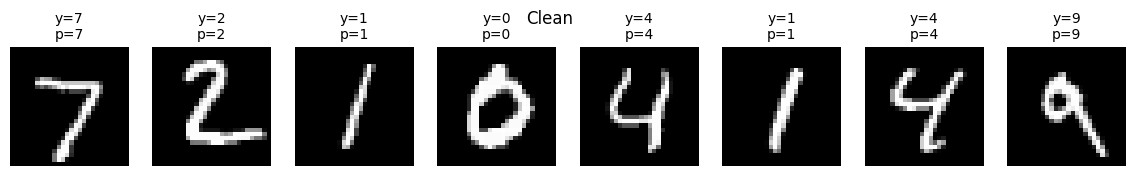

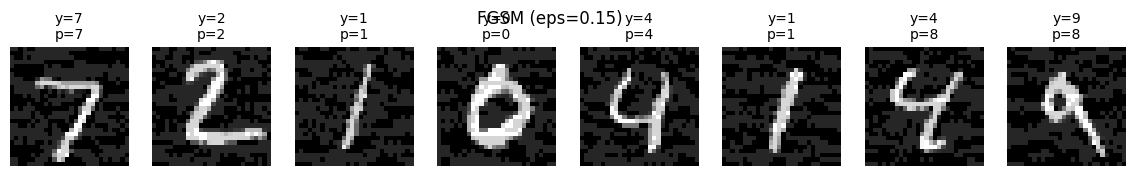

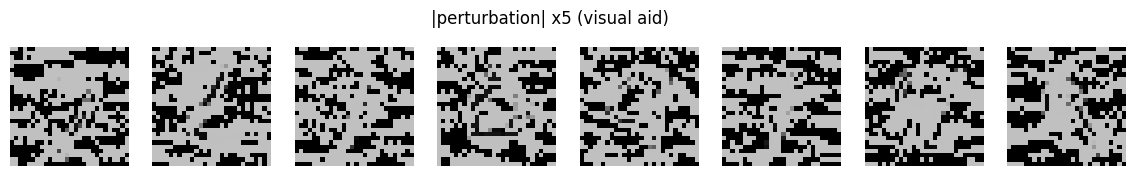

In [ ]:
x, y = next(iter(test_loader))
x, y = x.to(device), y.to(device)

with torch.no_grad():
    p_clean = predict(model, x)

eps = 0.15
x_fgsm = fgsm_attack(model, x, y, eps=eps, targeted=False)

with torch.no_grad():
    p_adv = predict(model, x_fgsm)

print("Clean acc on this batch:", (p_clean == y).float().mean().item())
print("FGSM  acc on this batch:", (p_adv == y).float().mean().item())
print("Max L_inf in batch:", l_inf_norm(x_fgsm, x).max().item())

show_batch(x[:8], labels=y[:8], preds=p_clean[:8], title="Clean")
show_batch(x_fgsm[:8], labels=y[:8], preds=p_adv[:8], title=f"FGSM (eps={eps})")
show_batch((x_fgsm - x).abs()[:8] * 5, title="|perturbation| x5 (visual aid)")


In [ ]:
def pgd_attack(model, x, y, eps, alpha, steps, random_start=True,
               targeted=False, y_target=None):
    """
    PGD in L_inf ball around x.
    Untargeted: maximize CE loss wrt y.
    Targeted:   minimize CE loss wrt y_target.
    """
    model.eval()

    x_orig = x.detach()
    if random_start:
        # uniform noise in [-eps, eps]
        x_adv = x_orig + (2*torch.rand_like(x_orig) - 1.0) * eps
        x_adv = clamp01(x_adv)
    else:
        x_adv = x_orig.clone()

    for _ in range(steps):
        x_adv = x_adv.clone().detach().requires_grad_(True)
        logits = model(x_adv)

        if targeted:
            assert y_target is not None, "Provide y_target for targeted PGD."
            loss = F.cross_entropy(logits, y_target)
            grad = torch.autograd.grad(loss, x_adv)[0]
            x_adv = x_adv - alpha * grad.sign()
        else:
            loss = F.cross_entropy(logits, y)
            grad = torch.autograd.grad(loss, x_adv)[0]
            x_adv = x_adv + alpha * grad.sign()

        # Project back to L_inf ball around x_orig
        delta = torch.clamp(x_adv - x_orig, min=-eps, max=eps)
        x_adv = clamp01(x_orig + delta)

    return x_adv.detach()


PGD acc on this batch: 0.046875
Max L_inf in batch: 0.20000001788139343


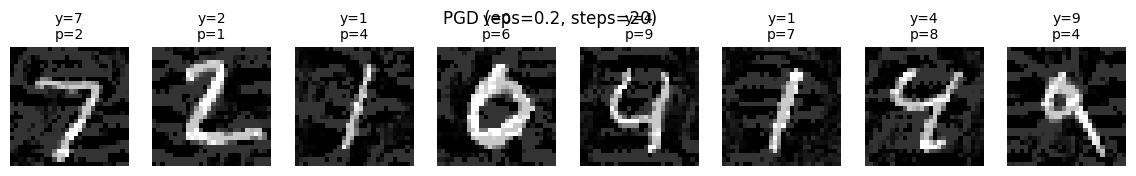

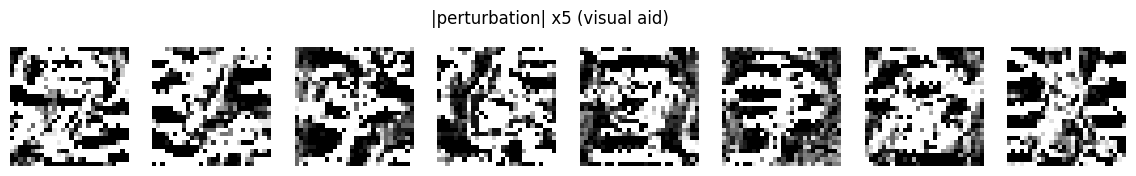

In [ ]:
eps = 0.20
alpha = 0.02
steps = 20

x_pgd = pgd_attack(model, x, y, eps=eps, alpha=alpha, steps=steps, random_start=True)

with torch.no_grad():
    p_pgd = predict(model, x_pgd)

print("PGD acc on this batch:", (p_pgd == y).float().mean().item())
print("Max L_inf in batch:", l_inf_norm(x_pgd, x).max().item())

show_batch(x_pgd[:8], labels=y[:8], preds=p_pgd[:8], title=f"PGD (eps={eps}, steps={steps})")
show_batch((x_pgd - x).abs()[:8] * 5, title="|perturbation| x5 (visual aid)")


In [ ]:
@torch.no_grad()
def eval_clean(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)
    return correct / total

def eval_under_attack(model, loader, attack_fn):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = attack_fn(x, y)
        with torch.no_grad():
            pred = model(x_adv).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)
    return correct / total


In [ ]:
eps_list = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]

clean_acc = eval_clean(model, test_loader)
print("Clean accuracy:", clean_acc)

fgsm_accs = []
pgd_accs  = []

for eps in eps_list:
    if eps == 0.0:
        fgsm_accs.append(clean_acc)
        pgd_accs.append(clean_acc)
        continue

    fgsm_acc = eval_under_attack(
        model, test_loader,
        attack_fn=lambda x, y, eps=eps: fgsm_attack(model, x, y, eps=eps)
    )
    pgd_acc = eval_under_attack(
        model, test_loader,
        attack_fn=lambda x, y, eps=eps: pgd_attack(model, x, y, eps=eps, alpha=eps/10, steps=20)
    )
    fgsm_accs.append(fgsm_acc)
    pgd_accs.append(pgd_acc)
    print(f"eps={eps:.2f}  FGSM={fgsm_acc*100:.2f}%  PGD={pgd_acc*100:.2f}%")


Clean accuracy: 0.9873
eps=0.05  FGSM=95.81%  PGD=95.10%
eps=0.10  FGSM=86.90%  PGD=81.09%
eps=0.15  FGSM=68.11%  PGD=43.38%
eps=0.20  FGSM=41.13%  PGD=5.55%


libc++abi: terminating due to uncaught exception of type std::__1::system_error: Broken pipe
libc++abi: terminating due to uncaught exception of type std::__1::system_error: Broken pipe
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x12448b880>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/revival/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/opt/anaconda3/envs/revival/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1628, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/opt/anaconda3/envs/revival/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/revival/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File

KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (6,) and (5,)

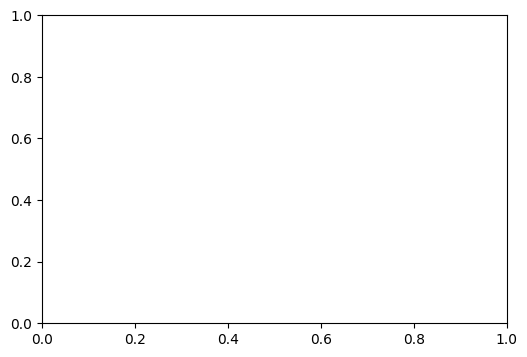

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(eps_list, fgsm_accs, marker="o", label="FGSM")
plt.plot(eps_list, pgd_accs,  marker="o", label="PGD (20 steps)")
plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend()
plt.title("Adversarial robustness on MNIST")
plt.show()


## Adversarial training (idea)

A common defense is **adversarial training**: during training, we mix clean inputs $x$ with adversarial inputs $x_{\text{adv}}$ crafted against the *current* model.

A standard formulation (Madry-style) is:

$\min_\theta \; \mathbb{E}_{(x,y)}\left[ \max_{\|\delta\|_\infty \le \varepsilon} \mathcal{L}(f_\theta(x+\delta), y) \right]$

Interpretation:

- The **inner maximization** finds a worst-case perturbation within an $\ell_\infty$ ball (a strong attacker).
- The **outer minimization** updates the model parameters $\theta$ to reduce the loss on those worst-case examples.

In practice we approximate the inner maximization with FGSM (fast, 1-step) or PGD (stronger, multi-step).


## Simple adversarial training with FGSM

We will implement a simple version of adversarial training:

1) Take a batch $(x, y)$  
2) Create adversarial examples with FGSM: $x_{\text{adv}} = \text{clip}(x + \varepsilon \cdot \text{sign}(\nabla_x \mathcal{L}(f_\theta(x), y)))$  
3) Train on a mixture of clean and adversarial examples.

We will use a mixing coefficient $\lambda \in [0,1]$:

$\mathcal{L}_{\text{mix}} = (1-\lambda)\,\mathcal{L}(f_\theta(x), y) + \lambda\,\mathcal{L}(f_\theta(x_{\text{adv}}), y)$

Typical observations:

- Clean accuracy may drop slightly
- Robust accuracy (under attack) improves substantially


In [ ]:
adv_model = SmallCNN().to(device)
adv_opt = torch.optim.Adam(adv_model.parameters(), lr=1e-3)


In [ ]:
def train_one_epoch_adv_fgsm(model, loader, optimizer, eps, lam=0.5):
    """
    Simple adversarial training:
    loss = (1-lam)*CE(clean) + lam*CE(adv)
    where adv is generated using FGSM on the current model.
    """
    model.train()
    total_loss, total = 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # --- generate adversarial examples (using current model) ---
        # We generate x_adv in "eval-style" but gradients wrt x are required.
        x_adv = fgsm_attack(model, x, y, eps=eps, targeted=False)

        # --- compute mixed loss and update parameters ---
        optimizer.zero_grad()
        logits_clean = model(x)
        logits_adv   = model(x_adv)

        loss_clean = F.cross_entropy(logits_clean, y)
        loss_adv   = F.cross_entropy(logits_adv, y)

        loss = (1 - lam) * loss_clean + lam * loss_adv
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    return total_loss / total


In [ ]:
adv_eps = 0.20   # adversarial training strength
lam = 0.5        # mix ratio
epochs = 3

for epoch in range(epochs):
    loss = train_one_epoch_adv_fgsm(adv_model, train_loader, adv_opt, eps=adv_eps, lam=lam)
    clean_acc = eval_clean(adv_model, test_loader)
    print(f"[adv-train] epoch={epoch+1} loss={loss:.4f} clean_test_acc={clean_acc*100:.2f}%")


Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/opt/anaconda3/envs/revival/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/opt/anaconda3/envs/revival/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^    ^exitcode = _main(fd, parent_sentinel)
^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/revival/lib/python3.12/multiprocessing/spawn.py", line 132, in _main
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/revival/lib/python3.12/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/revival/lib/python3.12/site-packages/torch/multiprocessing/reductions.py", line 560, in rebuild_storage_filename
    self = reduction.pickle.load(from_parent)
       

RuntimeError: DataLoader worker (pid(s) 38155) exited unexpectedly